# 01｜資料初探：worldcities.csv

**115-1 地理資訊系統運用程式**。這份 notebook 讀取 `data/raw/worldcities.csv`，先檢查欄位型態與缺值，再找出全球人口最多的城市，最後聚焦臺灣的城市資料。

## 1. 路徑設定

沿用 `00_Colab環境設定範本.ipynb` 的路徑設定：在 Colab 掛載 Google Drive，本機執行時則以 notebook 上一層作為專案資料夾。之後一律用 `RAW_DIR`、`PROCESSED_DIR`、`OUTPUT_DIR` 組合路徑。

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/115-1_GISprog")
else:
    # 備援：本機執行時，notebook 位於 115-1_GISprog/notebooks/，上一層就是專案資料夾
    PROJECT_DIR = Path.cwd().parent

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FONT_DIR = PROJECT_DIR / "fonts"

if not RAW_DIR.exists():
    raise FileNotFoundError(f"找不到 {RAW_DIR}，請確認 115-1_GISprog 資料夾位置是否正確")

print("執行環境：", "Google Colab" if IN_COLAB else "本機")
print("專案資料夾：", PROJECT_DIR)
print("原始資料：", sorted(p.name for p in RAW_DIR.iterdir()))

執行環境： 本機
專案資料夾： c:\作業資料夾\112-1~114-2 程式設計相關課程\課堂習題或回家作業\python\python\GIS_Programming
原始資料： ['worldcities.csv', '資料來源說明.md']


## 2. 中文字型

沿用 `00` 的字型設定，讓長條圖的中文標題與標籤可以正常顯示，不會變成方框。

In [2]:
import urllib.request

import matplotlib.pyplot as plt
from matplotlib import font_manager

FONT_URL = "https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download"
FONT_PATH = FONT_DIR / "TaipeiSansTCBeta-Regular.ttf"

if not FONT_PATH.exists():
    FONT_DIR.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

font_manager.fontManager.addfont(str(FONT_PATH))
plt.rcParams["font.family"] = "Taipei Sans TC Beta"
plt.rcParams["axes.unicode_minus"] = False  # 讓負號正常顯示
print("已設定中文字型：", FONT_PATH.name)

已設定中文字型： TaipeiSansTCBeta-Regular.ttf


## 3. 讀取資料

讀取全球城市資料 `worldcities.csv`。資料來源與授權說明見 `data/raw/資料來源說明.md`，該檔案不提供欄位定義，所以底下會直接檢查資料內容來判讀欄位意義。

In [3]:
import pandas as pd

df = pd.read_csv(RAW_DIR / "worldcities.csv")
print("資料筆數與欄位數：", df.shape)
df.head()

資料筆數與欄位數： (15493, 11)


,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
0,Tokyo,Tokyo,35.6850,139.7514,Japan,JP,JPN,Tōkyō,primary,35676000.0,1392685764
1,New York,New York,40.6943,-73.9249,United States,US,USA,New York,NaN,19354922.0,1840034016
2,Mexico City,Mexico City,19.4424,-99.1310,Mexico,MX,MEX,Ciudad de México,primary,19028000.0,1484247881
3,Mumbai,Mumbai,19.0170,72.8570,India,IN,IND,Mahārāshtra,admin,18978000.0,1356226629
4,São Paulo,Sao Paulo,-23.5587,-46.6250,Brazil,BR,BRA,São Paulo,admin,18845000.0,1076532519


## 4. 欄位與型態

先看每個欄位被 pandas 讀成什麼資料型態。

In [4]:
df.dtypes

city           object
city_ascii     object
lat           float64
lng           float64
country        object
iso2           object
iso3           object
admin_name     object
capital        object
population    float64
id              int64
dtype: object

## 5. 缺值統計

再看看哪些欄位有缺值、缺了多少筆。

In [5]:
df.isna().sum()

city              0
city_ascii        0
lat               0
lng               0
country           0
iso2             31
iso3              0
admin_name      191
capital       10247
population     1685
id                0
dtype: int64

## 6. 人口前 20 大城市

依 `population` 欄位排序，找出全世界人口最多的 20 個城市。`population` 缺值的列會被自動排除在外。

In [6]:
top20 = df.nlargest(20, "population")
top20[["city", "country", "population"]]

,city,country,population
0,Tokyo,Japan,35676000.0
1,New York,United States,19354922.0
2,Mexico City,Mexico,19028000.0
3,Mumbai,India,18978000.0
4,São Paulo,Brazil,18845000.0
5,Delhi,India,15926000.0
6,Shanghai,China,14987000.0
7,Kolkata,India,14787000.0
8,Los Angeles,United States,12815475.0
9,Dhaka,Bangladesh,12797394.0


## 7. 臺灣所有城市

篩選 `country` 為 `Taiwan` 的城市，依人口由高到低排序。實際檢查 `capital` 欄位的內容後，發現只有四種值：`primary`（國家首都）、`admin`（縣市層級的行政中心）、`minor`（較小的行政中心）、空白（不是行政中心）。

In [7]:
taiwan = df[df["country"] == "Taiwan"].sort_values("population", ascending=False)
print("臺灣城市筆數：", len(taiwan))
taiwan[["city", "admin_name", "capital", "population"]]

臺灣城市筆數： 27


,city,admin_name,capital,population
35,Taipei,Taipei,primary,6900273.0
136,Kaohsiung,Kaohsiung,admin,2769072.0
145,Taichung,Taichung,admin,2629323.0
224,Tainan,Tainan,admin,1876312.0
273,Zhongli,Taoyuan,NaN,1632616.0
799,Hsinchu,Hsinchu,admin,750000.0
800,Changhua,Changhua,admin,750000.0
1042,Pingtung,Pingtung,admin,503530.0
1051,Taoyuan District,Taoyuan,admin,500000.0
1052,Keelung,Keelung,admin,500000.0


## 8. 臺灣城市人口長條圖

畫圖前先排除 `population` 缺值的城市，並印出被排除的筆數。

In [8]:
taiwan_pop = taiwan.dropna(subset=["population"])
print("缺少人口資料而被排除的城市數：", len(taiwan) - len(taiwan_pop))

缺少人口資料而被排除的城市數： 3


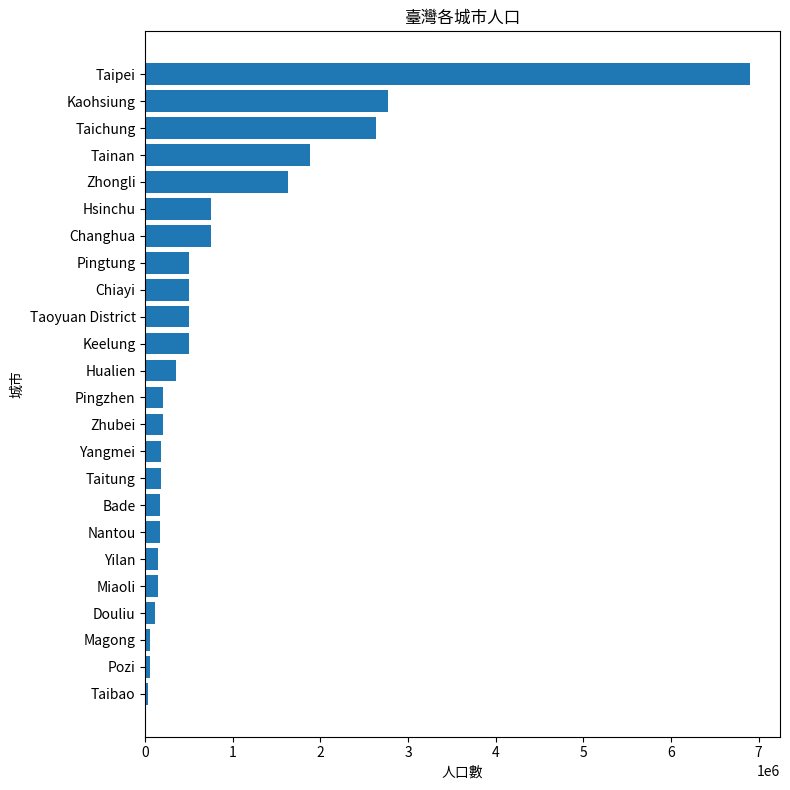

In [9]:
taiwan_sorted = taiwan_pop.sort_values("population")

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(taiwan_sorted["city"], taiwan_sorted["population"])
ax.set_title("臺灣各城市人口")
ax.set_xlabel("人口數")
ax.set_ylabel("城市")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_taiwan_population.png", dpi=150)
plt.show()